In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving customer-churn-training.csv to customer-churn-training.csv


In [4]:
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (12, 7)


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        12 non-null     object
 1   tenure_months      12 non-null     int64 
 2   support_tickets    12 non-null     int64 
 3   monthly_spend_inr  12 non-null     int64 
 4   last_login_days    12 non-null     int64 
 5   plan_type          12 non-null     object
 6   churned            12 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 804.0+ bytes

Missing values:
customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64

Duplicate rows: 0


In [6]:
TARGET_COLUMN = "target"

In [7]:
TARGET_COLUMN = "Outcome"

In [10]:
TARGET_COLUMN = "churned"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found.\n"
        f"Available columns are: {df.columns.tolist()}"
    )

print("Target column:", TARGET_COLUMN)

Target column: churned


In [11]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (12, 6)
Target shape: (12,)

Target distribution:
churned
0    7
1    5
Name: count, dtype: int64


In [12]:
categorical_columns = X.select_dtypes(include=["object", "category"]).columns
numerical_columns = X.select_dtypes(exclude=["object", "category"]).columns

print("Categorical columns:", list(categorical_columns))
print("Numerical columns:", list(numerical_columns))

Categorical columns: ['customer_id', 'plan_type']
Numerical columns: ['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days']


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [14]:
preprocessor = StandardScaler()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Training data: (9, 6)
Testing data: (3, 6)

Training target distribution:
churned
0    5
1    4
Name: count, dtype: int64


In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross Validation created successfully.")

5-Fold Stratified Cross Validation created successfully.


In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    )
}

print("Four classification models created:")
for name in models:
    print("-", name)

Four classification models created:
- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machine


In [18]:
param_grids = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [2, 3]
    },

    "Support Vector Machine": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}

print("Hyperparameter grids created successfully.")

Hyperparameter grids created successfully.


In [20]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical columns to numbers
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print(X.head())

   customer_id  tenure_months  support_tickets  monthly_spend_inr  \
0            0              2                4                499   
1            1             18                1               1299   
2            2              6                3                799   
3            3             30                0               1499   
4            4             11                2                999   

   last_login_days  plan_type  
0               21          0  
1                2          1  
2               14          0  
3                1          1  
4                5          2  


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV Score: 1.0


In [23]:
print(X.dtypes)
print(X.head())

customer_id          int64
tenure_months        int64
support_tickets      int64
monthly_spend_inr    int64
last_login_days      int64
plan_type            int64
dtype: object
   customer_id  tenure_months  support_tickets  monthly_spend_inr  \
0            0              2                4                499   
1            1             18                1               1299   
2            2              6                3                799   
3            3             30                0               1499   
4            4             11                2                999   

   last_login_days  plan_type  
0               21          0  
1                2          1  
2               14          0  
3                1          1  
4                5          2  


In [24]:
best_models = {}
cv_results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_

    print("\nBest Parameters:")
    print(grid_search.best_params_)

    print("Best Cross-Validation F1 Score:")
    print(round(grid_search.best_score_, 4))

    cv_results.append({
        "Model": name,
        "Best CV F1": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })


Training: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}
Best Cross-Validation F1 Score:
0.8

Training: Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation F1 Score:
0.8

Training: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
Best Cross-Validation F1 Score:
0.8

Training: Support Vector Machine
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation F1 Score:
0.8


In [25]:
tuning_results = pd.DataFrame(cv_results)

display(tuning_results)

,Model,Best CV F1,Best Parameters
0,Logistic Regression,0.8,"{'C': 0.01, 'solver': 'liblinear'}"
1,Random Forest,0.8,"{'max_depth': None, 'min_samples_split': 2, 'n..."
2,Gradient Boosting,0.8,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est..."
3,Support Vector Machine,0.8,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}"


In [26]:
results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # For binary classification
    if len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0
2,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0
3,Support Vector Machine,0.6667,0.8333,0.6667,0.6667,1.0


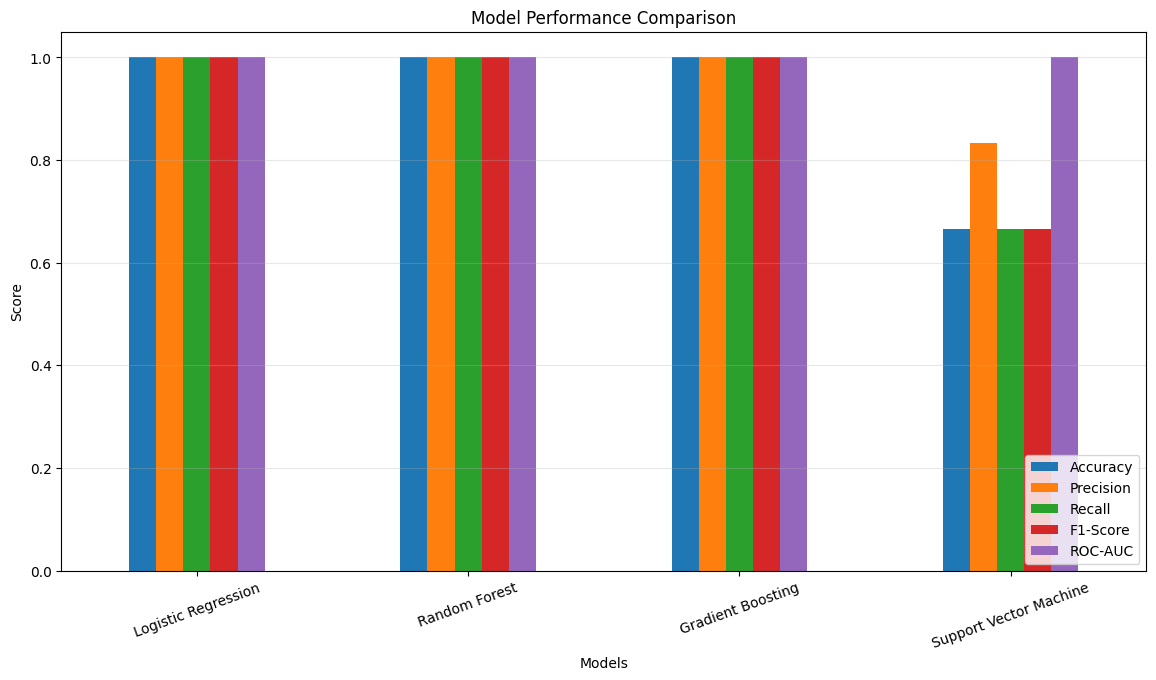

In [27]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

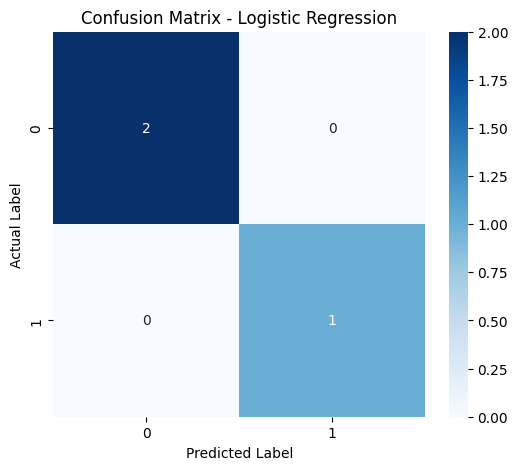

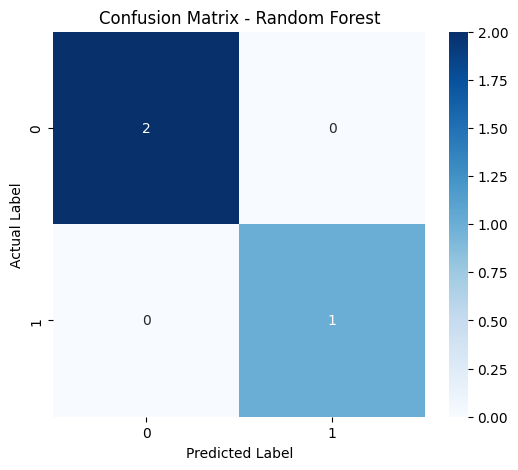

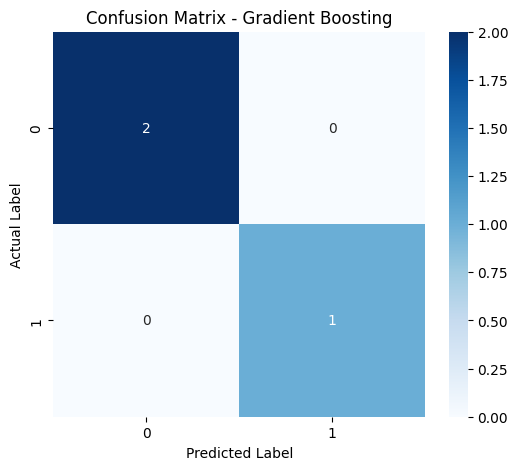

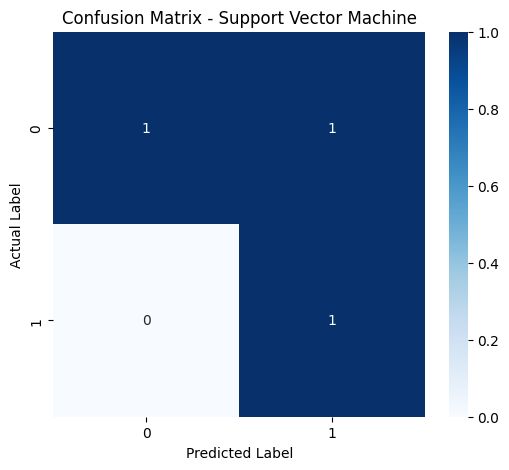

In [28]:
for name, model in best_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

In [29]:
for name, model in best_models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg    

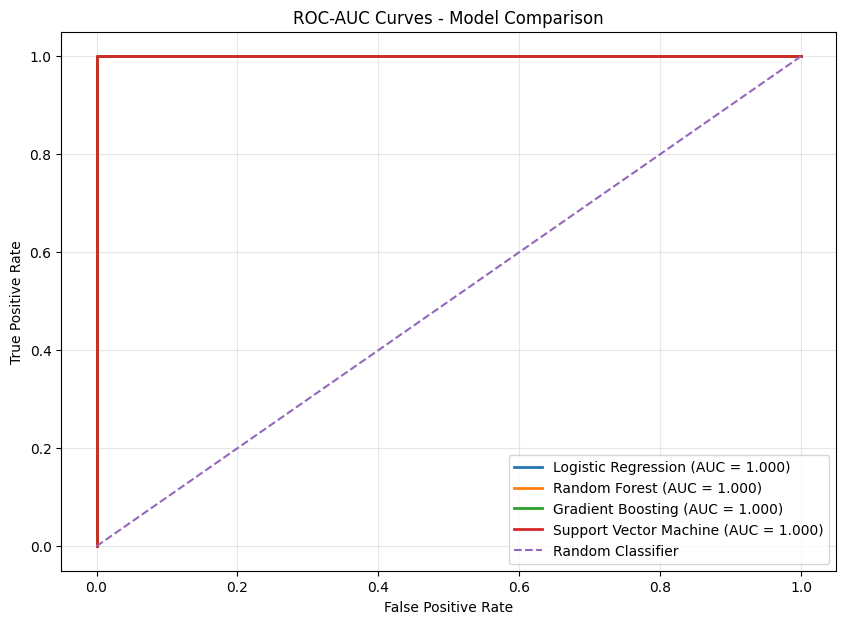

In [30]:
plt.figure(figsize=(10, 7))

for name, model in best_models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves - Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
champion_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

champion_name = champion_row["Model"]
champion_model = best_models[champion_name]

print("🏆 CHAMPION MODEL")
print("=" * 50)
print("Model:", champion_name)
print("Accuracy:", round(champion_row["Accuracy"], 4))
print("Precision:", round(champion_row["Precision"], 4))
print("Recall:", round(champion_row["Recall"], 4))
print("F1-Score:", round(champion_row["F1-Score"], 4))

if not pd.isna(champion_row["ROC-AUC"]):
    print("ROC-AUC:", round(champion_row["ROC-AUC"], 4))

🏆 CHAMPION MODEL
Model: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC: 1.0


In [32]:
print("Champion Model:")
print(champion_model)

print("\nBest Parameters:")
print(
    tuning_results[
        tuning_results["Model"] == champion_name
    ]["Best Parameters"].values[0]
)

Champion Model:
LogisticRegression(C=0.01, max_iter=2000, random_state=42, solver='liblinear')

Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}


In [33]:
model_filename = "champion_model.joblib"

joblib.dump(
    champion_model,
    model_filename
)

print("Model saved successfully!")
print("File:", model_filename)

Model saved successfully!
File: champion_model.joblib


In [34]:
loaded_model = joblib.load("champion_model.joblib")

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
LogisticRegression(C=0.01, max_iter=2000, random_state=42, solver='liblinear')


In [35]:
loaded_predictions = loaded_model.predict(X_test)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print(
    "Accuracy of loaded model:",
    round(loaded_accuracy, 4)
)

Accuracy of loaded model: 1.0


In [36]:
from google.colab import files

files.download("champion_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved!")

Model comparison results saved!


In [38]:
files.download("model_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print("=" * 70)
print("RAB TECH ACADEMY - TASK 04")
print("SUPERVISED CLASSIFICATION MODELING & TUNING")
print("=" * 70)

print("\nModels Trained:")
for model_name in best_models:
    print("✓", model_name)

print("\nChampion Model:")
print("🏆", champion_name)

print("\nChampion Performance:")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]:
    value = champion_row[metric]

    if not pd.isna(value):
        print(f"{metric}: {value:.4f}")

print("\nModel file:")
print("✓ champion_model.joblib")

print("\nTask 04 completed successfully!")

RAB TECH ACADEMY - TASK 04
SUPERVISED CLASSIFICATION MODELING & TUNING

Models Trained:
✓ Logistic Regression
✓ Random Forest
✓ Gradient Boosting
✓ Support Vector Machine

Champion Model:
🏆 Logistic Regression

Champion Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000

Model file:
✓ champion_model.joblib

Task 04 completed successfully!


In [ ]:
RAB Tech Academy Task 04
│
├── 1. Install Libraries
│
├── 2. Import Libraries
│
├── 3. Load Dataset
│
├── 4. Explore Dataset
│
├── 5. Select Target Column
│
├── 6. Separate X and y
│
├── 7. Train-Test Split
│
├── 8. Stratified K-Fold Cross Validation
│
├── 9. Define 4 Models
│     ├── Logistic Regression
│     ├── Random Forest
│     ├── Gradient Boosting
│     └── SVM
│
├── 10. Define Hyperparameters
│
├── 11. GridSearchCV
│
├── 12. Best Parameters
│
├── 13. Model Comparison
│
├── 14. Precision
│
├── 15. Recall
│
├── 16. F1-Score
│
├── 17. ROC-AUC
│
├── 18. Confusion Matrices
│
├── 19. ROC-AUC Curves
│
├── 20. Champion Model
│
├── 21. Save Champion Model
│     └── champion_model.joblib
│
└── 22. Final Summary